In [1]:
# Práctica 9: Text analysis: Create a word cloud from text data.
# Se usarán ambos dataset, el limpio que se ha usado en práctica pasadas y el que se uso en la práctica pasada
import pandas as pd

df = pd.read_csv("ncr_ride_bookings.csv")

df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna('Not cancelled')
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0)
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna('Not cancelled')
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0)
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].fillna('Not incomplete')
df['Booking Value'] = df['Booking Value'].fillna(0)
df['Ride Distance'] = df['Ride Distance'].fillna(0)
df['Driver Ratings'] = df['Driver Ratings'].fillna(0)
df['Customer Rating'] = df['Customer Rating'].fillna(0)
df['Avg CTAT'] = df['Avg CTAT'].fillna(0)
df['Avg VTAT'] = df['Avg VTAT'].fillna(0)
df['Payment Method'] = df['Payment Method'].fillna('Cancelled or incomplete ride')
df['is_cancelled'] = (df['Cancelled Rides by Customer'] == 1) | (df['Cancelled Rides by Driver'] == 1)
df['is_cancelled'] = df['is_cancelled'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55447 entries, 0 to 55446
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               55447 non-null  object 
 1   Time                               55447 non-null  object 
 2   Booking ID                         55447 non-null  object 
 3   Booking Status                     55447 non-null  object 
 4   Customer ID                        55447 non-null  object 
 5   Vehicle Type                       55447 non-null  object 
 6   Pickup Location                    55447 non-null  object 
 7   Drop Location                      55447 non-null  object 
 8   Avg VTAT                           55447 non-null  float64
 9   Avg CTAT                           55447 non-null  float64
 10  Cancelled Rides by Customer        55447 non-null  float64
 11  Reason for cancelling by Customer  55447 non-null  obj

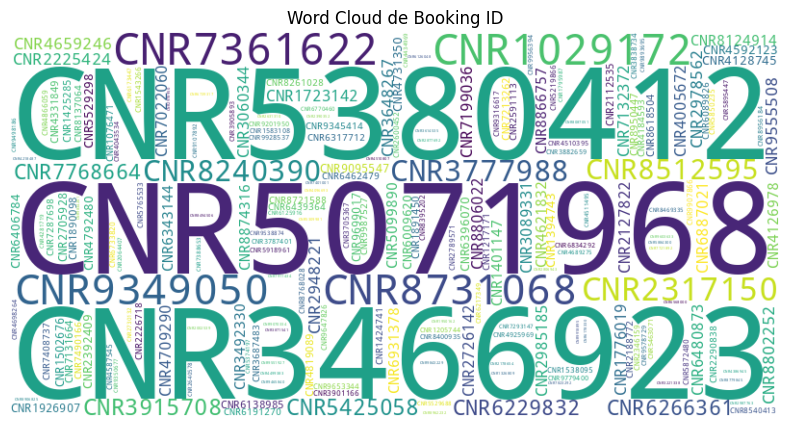

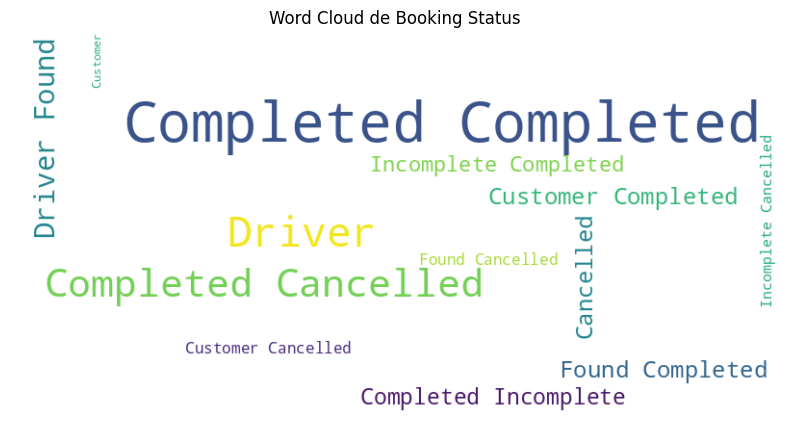

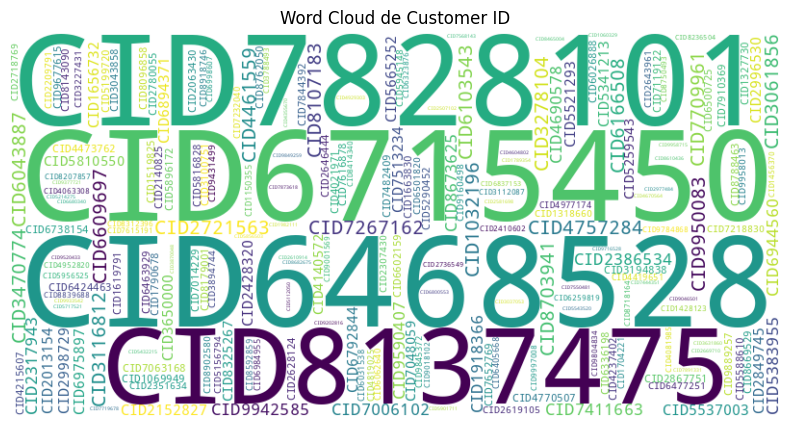

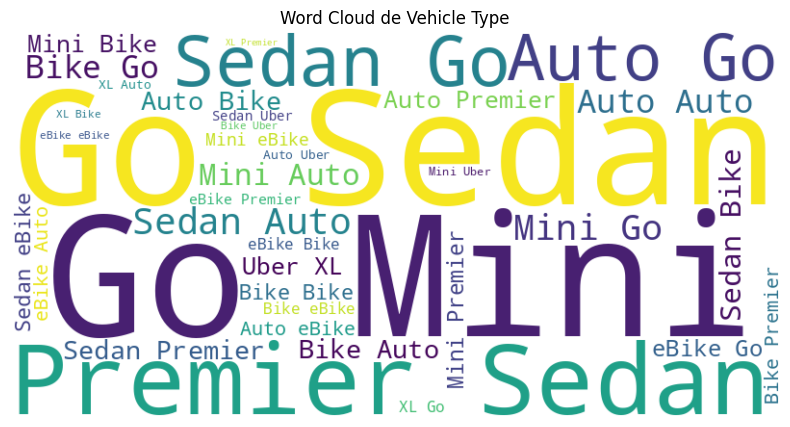

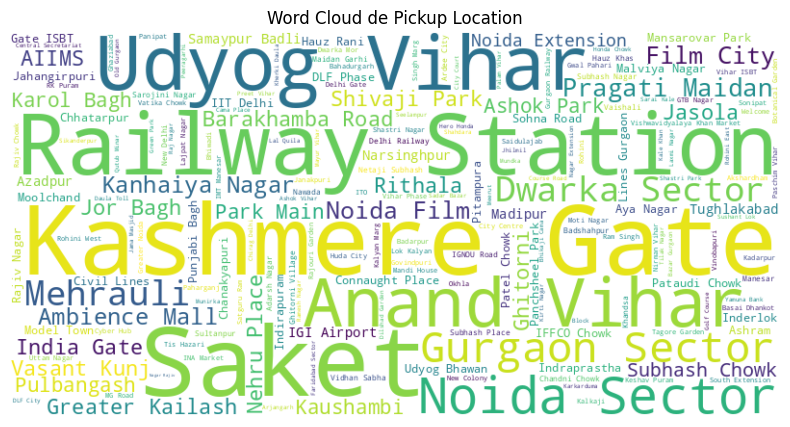

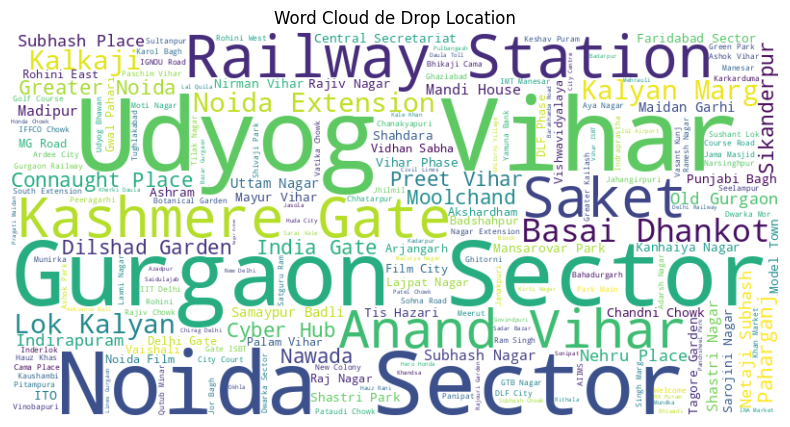

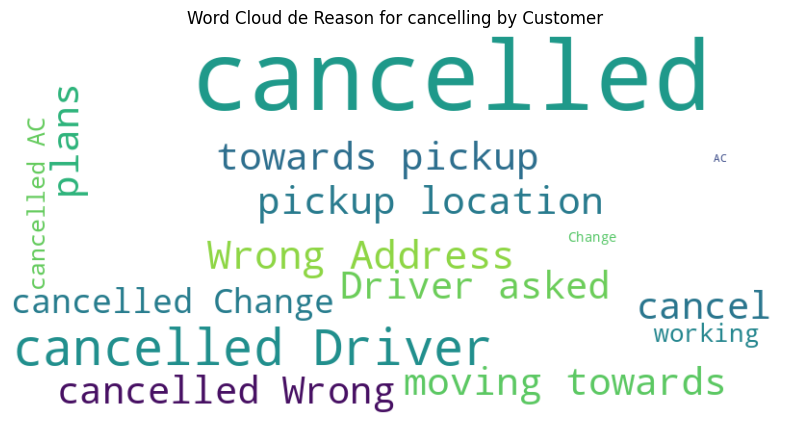

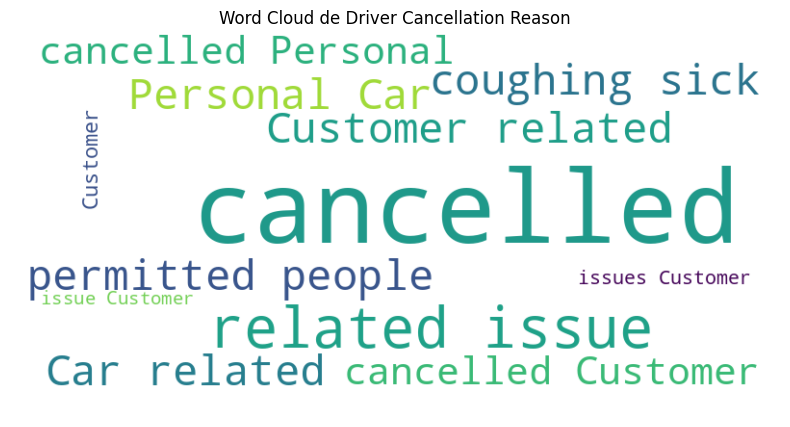

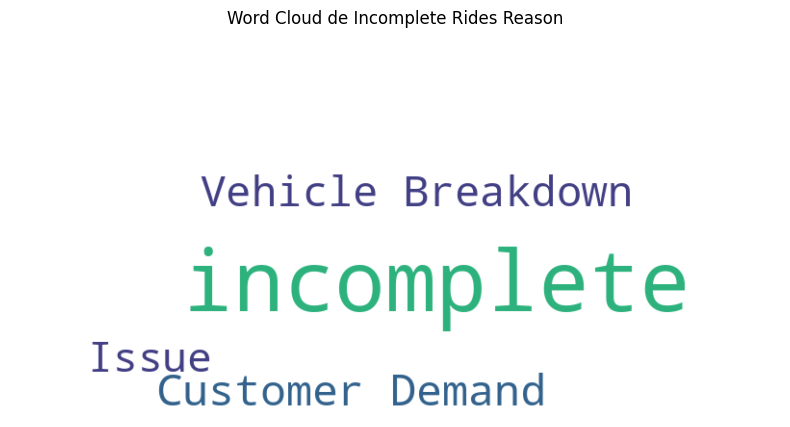

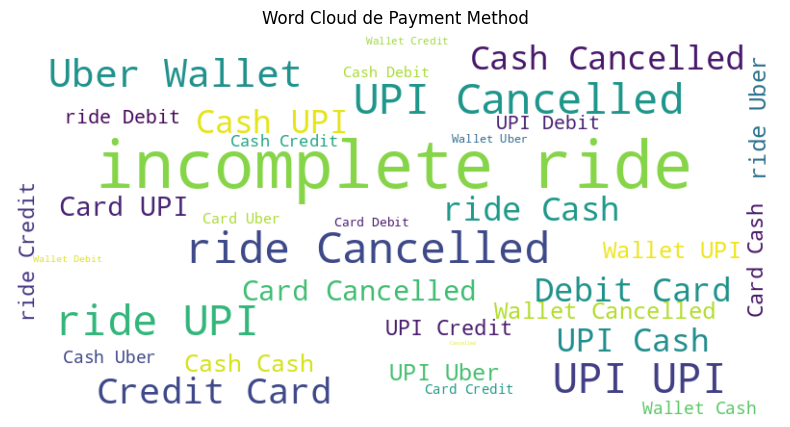

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_columns = df.select_dtypes(include='object').columns.tolist()
excluded_columns = ['Date', 'Time','is_cancelled']
text_columns = [col for col in text_columns if col not in excluded_columns]

for col in text_columns:
    text_data = df[col].fillna('')
    full_text = ' '.join(text_data.values)

    full_text.strip()
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(full_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud de {col}')
    plt.show()

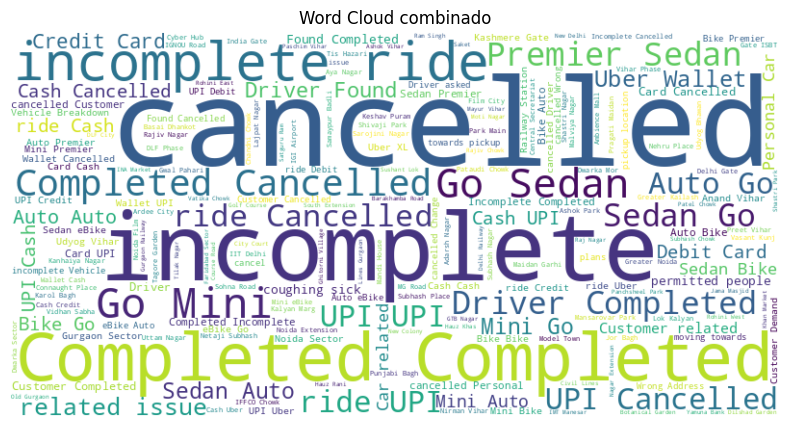

In [12]:
all_text = ''

for col_name in text_columns:
    all_text += ' '.join(df[col_name].fillna('').astype(str).values) + ' '

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud combinado')
plt.show()

In [6]:
# Datos limpios (Dataset usado normalmente)
df2 = pd.read_csv('datos_limpios.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93000 entries, 0 to 92999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Booking ID       93000 non-null  object 
 1   Booking Status   93000 non-null  object 
 2   Customer ID      93000 non-null  object 
 3   Vehicle Type     93000 non-null  object 
 4   Pickup Location  93000 non-null  object 
 5   Drop Location    93000 non-null  object 
 6   Avg VTAT         93000 non-null  float64
 7   Avg CTAT         93000 non-null  float64
 8   Booking Value    93000 non-null  float64
 9   Ride Distance    93000 non-null  float64
 10  Driver Ratings   93000 non-null  float64
 11  Customer Rating  93000 non-null  float64
 12  Payment Method   93000 non-null  object 
 13  Datetime         93000 non-null  object 
dtypes: float64(6), object(8)
memory usage: 9.9+ MB


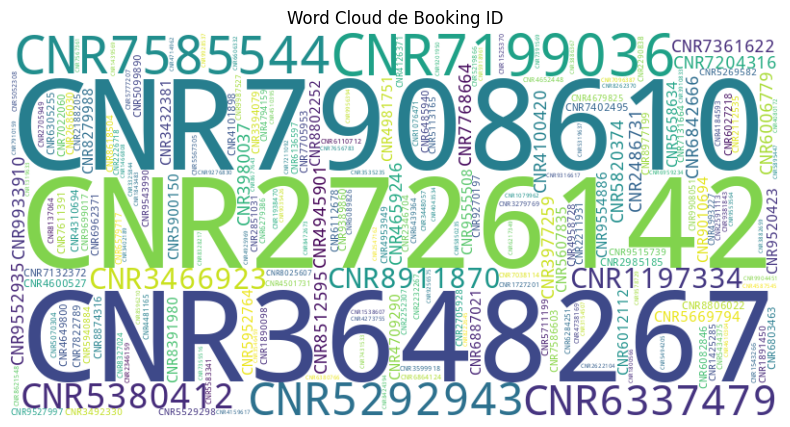

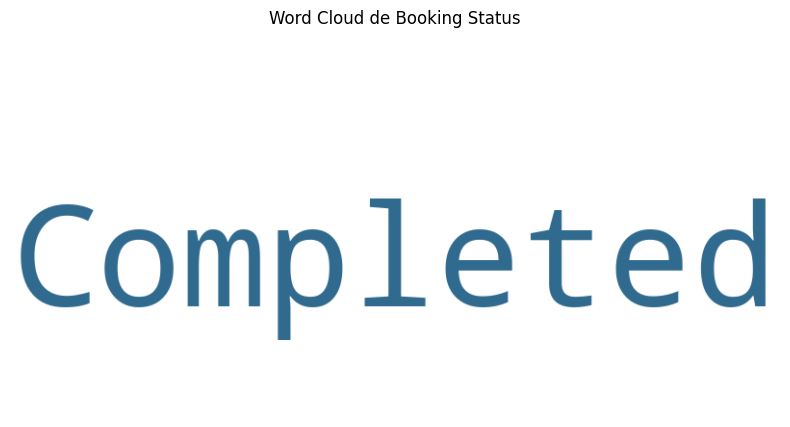

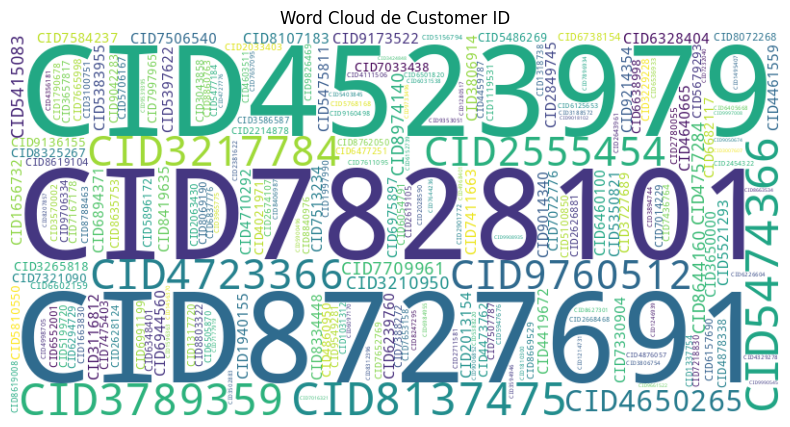

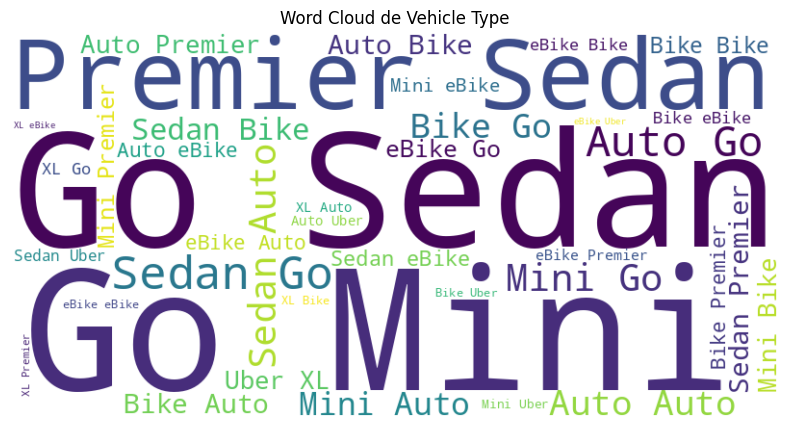

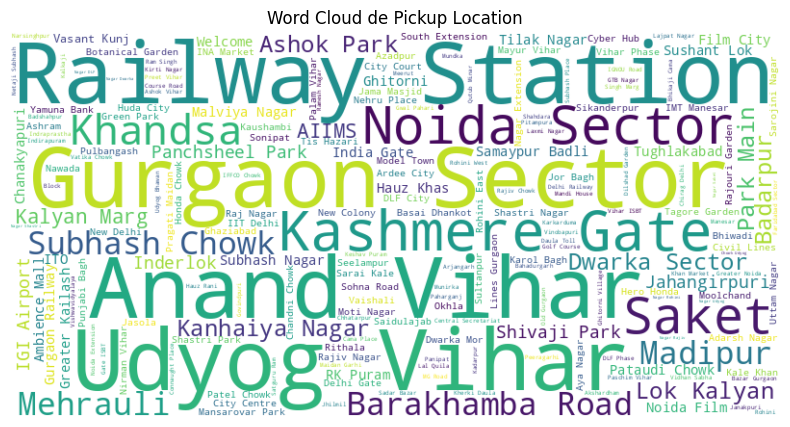

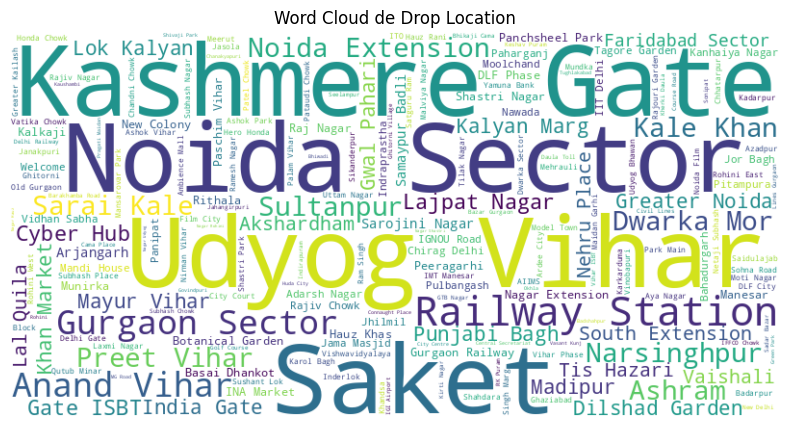

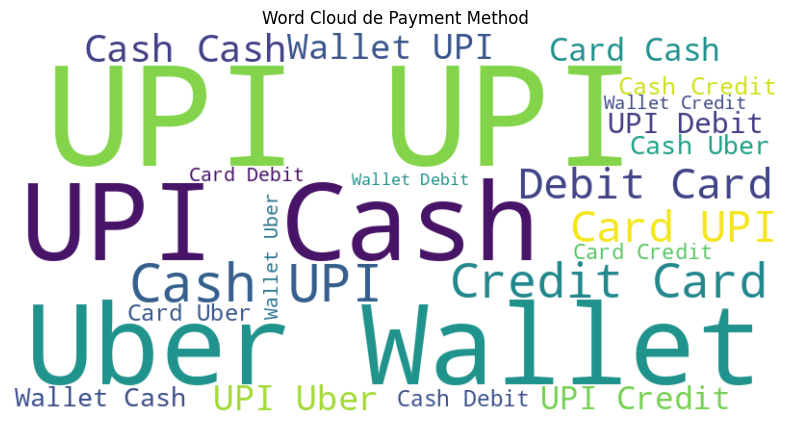

In [13]:
text_columns = df2.select_dtypes(include='object').columns.tolist()
excluded_columns = ['Datetime']
text_columns = [col for col in text_columns if col not in excluded_columns]

for col in text_columns:
    text_data = df2[col].fillna('')
    full_text = ' '.join(text_data.values)

    full_text.strip()
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(full_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud de {col}')
    plt.show()

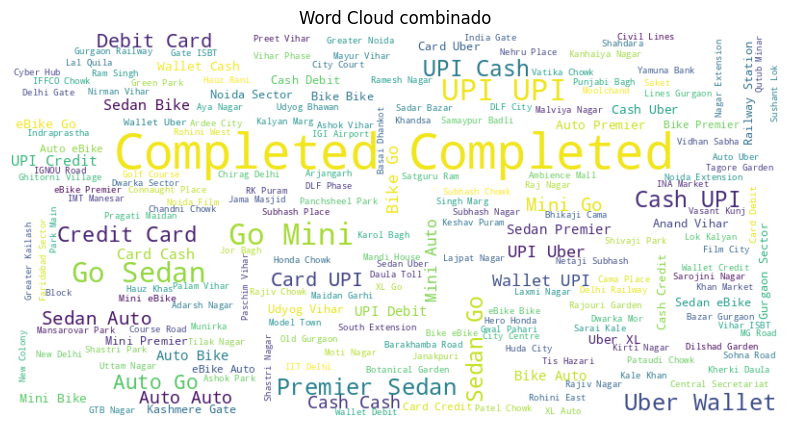

In [14]:
all_text = ''

for col_name in text_columns:
    all_text += ' '.join(df2[col_name].fillna('').astype(str).values) + ' '

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud combinado')
plt.show()